In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import silhouette_score

In [2]:
#Load Processed Dataset
df = pd.read_csv("processed_data.csv")

df.head()

,customer_id,product_id,quantity,price,transaction_date,payment_method,store_location,product_category,discount,total_amount
0,109318,C,7,80.079844,26-12-2023 12:32,Cash,"176 Andrew Cliffs\nBaileyfort, HI 93354",Books,18.677100,455.862764
1,993229,C,4,75.195229,05-08-2023 00:00,Cash,"11635 William Well Suite 809\nEast Kara, MT 19483",Home Decor,14.121365,258.306546
2,579675,A,8,31.528816,11-03-2024 18:51,Cash,"910 Mendez Ville Suite 909\nPort Lauraland, MO...",Books,15.943701,212.015651
3,799826,D,5,98.880218,27-10-2023 22:00,PayPal,"87522 Sharon Corners Suite 500\nLake Tammy, MO...",Books,6.686337,461.343769
4,121413,A,7,93.188512,22-12-2023 11:38,Cash,"0070 Michelle Island Suite 143\nHoland, VA 80142",Electronics,4.030096,626.030484


In [3]:
print(df.columns)

Index(['customer_id', 'product_id', 'quantity', 'price', 'transaction_date',
       'payment_method', 'store_location', 'product_category', 'discount',
       'total_amount'],
      dtype='object')


In [4]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

/tmp/ipykernel_1959/3937442087.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['transaction_date'] = pd.to_datetime(df['transaction_date'])


In [5]:
today = df['transaction_date'].max() + pd.Timedelta(days=1)

In [6]:
rfm = df.groupby('customer_id').agg({
    'transaction_date': lambda x: (today - x.max()).days,
    'customer_id': 'count',
    'total_amount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.reset_index(inplace=True)

rfm.head()

,customer_id,Recency,Frequency,Monetary
0,14,267,1,256.232791
1,42,346,1,502.656523
2,49,329,1,21.399047
3,59,28,2,249.492696
4,65,316,1,548.006625


In [7]:
X = rfm[['Recency', 'Frequency', 'Monetary']]

In [8]:
#Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

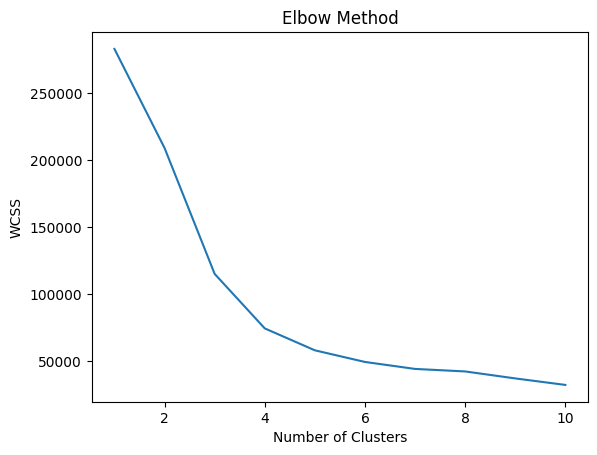

In [9]:
#Elbow Method (Find Optimal K)
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [11]:
print(rfm.columns)

Index(['customer_id', 'Recency', 'Frequency', 'Monetary'], dtype='object')


In [12]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm[['Recency', 'Frequency', 'Monetary']])

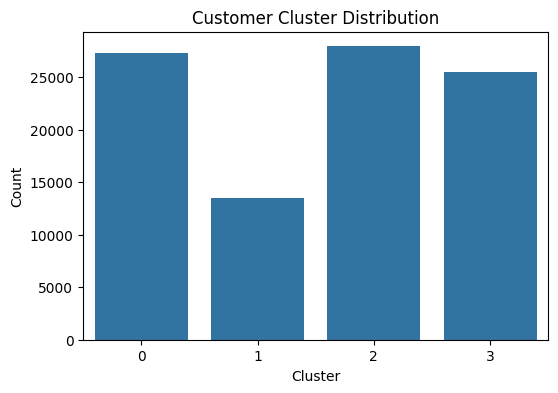

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x='Cluster', data=rfm)

plt.title("Customer Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Count")

plt.show()

In [15]:
from sklearn.decomposition import PCA

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

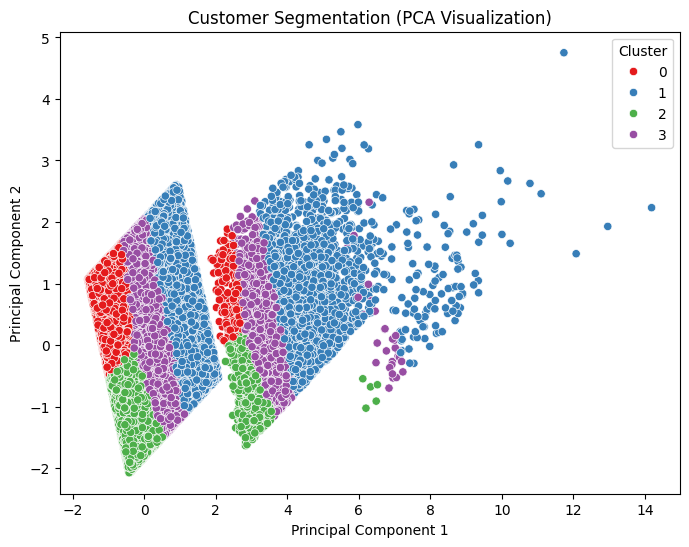

In [16]:
# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create DataFrame
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = rfm['Cluster']

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df, palette='Set1')

plt.title("Customer Segmentation (PCA Visualization)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

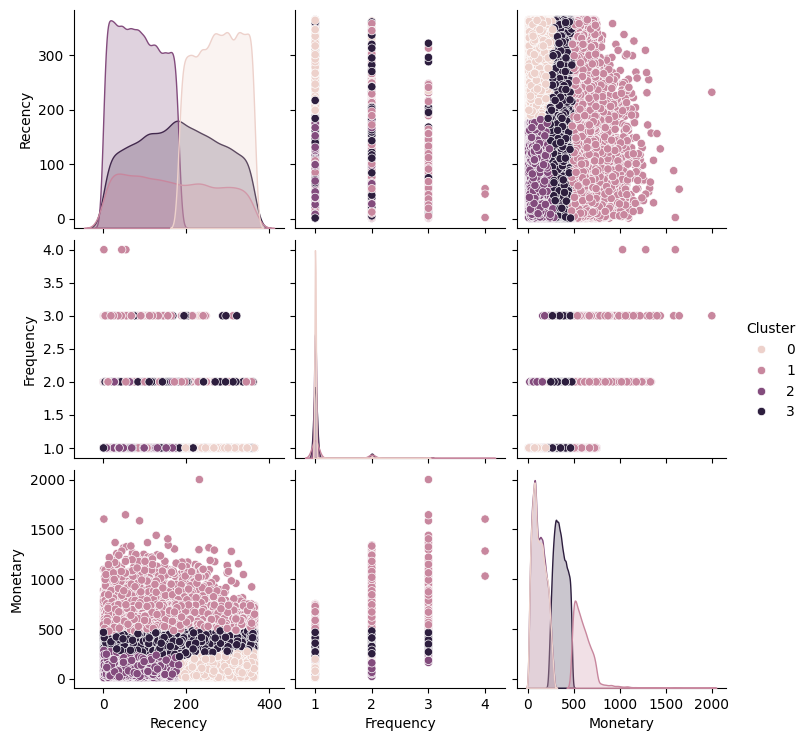

In [17]:
sns.pairplot(rfm[['Recency','Frequency','Monetary','Cluster']], hue='Cluster')
plt.show()

In [18]:
cluster_summary = rfm.groupby('Cluster').mean()
print(cluster_summary)

           customer_id     Recency  Frequency    Monetary
Cluster                                                  
0        498760.542754  276.646445   1.008049  123.399030
1        504252.723324  170.080509   1.171230  604.008502
2        500660.747942   87.821999   1.023982  124.300163
3        499133.074051  181.857429   1.058637  353.427054


 **Cluster Interpretation**
 **Cluster 0 → Lost / Inactive Customers**
*  Very high Recency (haven’t purchased in long time)
*  Low spending

* Meaning: Customers who stopped buying
* Action: Discounts, re-engagement campaigns

 **Cluster 1 → High-Value Customers**

*  Highest Monetary
*  Highest Frequency
*  Medium Recency

* Meaning: Best customers
* Action: Loyalty programs, VIP offers
offers

 **Cluster 2 → New / Recent Customers**
* Low Recency (recently purchased)
* Low spending

* Meaning: New or occasional buyers
* Action: Encourage repeat purchases

**Cluster 3 → Regular Customers**
* Medium Recency
* Medium Monetary

* Meaning: Average customers
* Action: Upsell / cross-sell
  


